📅 **论文年份 (Year):2022 / 2023 年**
*Flamingo: a Visual Language Model for Few-Shot Learning — Alayrac et al., DeepMind (2022)*
*BLIP-2: Bootstrapping Language-Image Pre-training with Frozen Image Encoders and Large Language Models — Li et al., Salesforce (2023)*

# Bonus Paper 33: BLIP-2 与 Flamingo(模态桥接)
## Li et al., Salesforce & Alayrac et al., DeepMind(李俊男等 & 阿莱拉克等)

### Implementation: A Tiny Q-Former Bridge with Flamingo-style Tanh Gating(实现:带 Flamingo 式 tanh 门控的微型 Q-Former 桥)

This notebook demonstrates the core idea shared by BLIP-2 and Flamingo using only NumPy: **freeze both a pretrained image encoder and a pretrained language model, and train only a tiny "bridge"** — K learnable queries that cross-attend over image patch features and emit visual prefix embeddings — so the frozen LM learns to "see" images and caption them, token by token.

本笔记本只用 NumPy 演示 BLIP-2 与 Flamingo 共享的核心思想:**两侧大模型(图像编码器 + 语言模型)全部冻结,只训练中间一座极小的"桥"**——K 个可学习 query 向量对图像 patch 特征做 cross-attention,输出视觉前缀嵌入喂给冻结 LM,让它逐 token 生成正确标题。桥的输出还加上 Flamingo 式的 tanh 门控(初始化为 0),保证训练开始时桥完全不干扰 LM。

> 注:BLIP-2 与 Flamingo 不在 Sutskever 原始 30 篇书单中,是本仓库的多模态扩展(Bonus)。它们是"冻结大模型 + 轻量适配"这一现代多模态范式的奠基之作。

## 📖 论文导读

**🎯 这篇文章想解决什么问题(目的):** 视觉-语言模型的端到端预训练(如 CLIP 之后的各类 VLM)成本极高:图像塔和语言塔都要从头训练或整体微调,数十亿参数全部参与梯度更新。但 2022 年前后,社区已经拥有极强的**现成**单模态模型——预训练视觉编码器和大语言模型。Flamingo 与 BLIP-2 问的是同一个问题:能否把这两个冻结的"巨人"直接连起来,只训练中间很小的连接件,就获得看图说话的能力?

**💡 主要贡献:** Flamingo(2022)把**门控 cross-attention 层**(gated xattn-dense)插进冻结的 Chinchilla LM,门控用 tanh 且初始化为 0——训练开始时模型行为与纯 LM 完全一致,视觉信息随门的打开逐渐流入,这是大规模训练不崩的关键;80B 参数中只训练约 10B 连接件,即获得强大的少样本多模态能力。BLIP-2(2023)更进一步:连接件缩小为一个 **Q-Former**——一组可学习 query 向量通过 cross-attention 从冻结 ViT 的 patch 特征中"提取"固定数量的视觉 token,再作为软前缀(soft prefix)喂给冻结 LLM;只训练 188M 参数(约为 FlanT5-XXL 版本总参数量的 2%),在 VQA 等任务上超过了可训练参数多 54 倍的 Flamingo-80B。

**🔧 方法:** 本笔记本把这套配方缩小一万倍并完整复现:(1) **Stage 0a** 在合成图形数据上预训练一个小图像编码器(输出 4×4=16 个 patch 特征而非单向量),冻结;(2) **Stage 0b** 在纯文本语料上预训练一个单层 RNN 语言模型(手写 BPTT),冻结;(3) **桥** = K 个可学习 query 对 16 个 patch 特征做 cross-attention,经一个小 MLP 投影成 K 个前缀嵌入,乘以 tanh(g)(g 初始化为 0)后插入冻结 LM 的输入序列;只有桥的约四千个参数参与更新——梯度会**穿过**冻结 LM 反传到前缀(冻结≠梯度不流过),但冻结参数一动不动。

**🌟 意义:** "冻结双塔 + 轻量桥"从此成为多模态的主流范式:LLaVA 的 projection 层、MiniGPT-4、Qwen-VL 的 resampler、GPT-4V 一系的适配器全是这条路线的后代。它的深层启示是:预训练大模型内部已经存在丰富的可复用计算通路,适配一个新模态不需要重学这些通路,只需要一个"翻译器"把新模态的信息写进 LM 已经听得懂的接口——本笔记本的消融实验将定量演示这一点。

## 🎯 核心结论 (Key Takeaways)

- **只训练 5.5% 的参数就让冻结 LM 看见了图像。** 桥只有 **4,225** 个参数(双塔合计 76,586:编码器 31,136 + LM 45,450),训练后冻结 LM 在 500 张新图像上的标题准确率达 **95.2%**;真实 BLIP-2 只训练 188M(约占 FlanT5-XXL 版本总量 2%)就超过了 Flamingo-80B。

- **冻结 ≠ 梯度不流过。** 训练时交叉熵梯度沿 BPTT **穿过**整个冻结 RNN 回传到视觉前缀,再传进桥;训练结束后逐参数检查,LM 与编码器的最大参数漂移均为 **0.0**——梯度必须流过冻结塔(否则桥收不到任何信号),但冻结参数从不更新。

- **tanh 门控让桥"先开门、再学内容"。** gate 初始化为 0 时前缀恒为零向量,输出与图像内容完全无关(训练前 500 张图只生成 **1 种**标题,准确率 10.0%)。注:Flamingo 的门在 LM 内部残差分支上,g=0 时逐位恒等于原 LM;本实现的门在输入前缀上,零前缀仍占据两个时间步、隐藏态相对纯文本情形有偏移(训练前损失 1.40 高于纯文本下限 0.549 即为证据);由于 prefix = tanh(g)·U,g=0 时所有注意力参数的梯度也为 0,只有 g 自己有梯度——门先打开一条缝,注意力内容随后才开始学习,最终 tanh(g) 稳定在约 **+0.10**。这正是 Flamingo 保证训练稳定的设计。

- **图像信息突破了纯文本 LM 的熵下限。** 冻结 LM 单独预测标题 4 个 token 的理论下限是 2·ln3/4 ≈ 0.549(颜色、形状各 ln3 不可预测);桥训练后同位置损失降到 **≈0.03**(训练批次低至 ≈0.003)——缺失的约 ln9≈2.2 nats 信息全部由图像经 4,225 参数的桥注入。

- **桥只能"解锁"冻结 LM 已有的能力,不能创造新能力。** 消融实验:同样的桥接到只见过 "a red circle" 式短句的 LM(语料中不存在"上文提到 X→后文描述 X"的条件结构),准确率只有约 **54%**;接到见过条件结构语料的 LM 则达 **95.2%**。BLIP-2 依赖的正是 LLM 预训练中已经学会的 in-context 条件生成通路。

- **两个 Stage 0 预训练都精确收敛到理论值。** 图像编码器 9 类分类测试准确率 **95.6%**;LM 纯文本损失收敛到 **0.3139**,与理论下限 2·ln3/7 ≈ 0.3139 完全一致,且对 9 条 prompt 的"复制通路"检验全部正确。

## 🤯 反常识的发现 (Counterintuitive Findings)

- **常识认为:参数冻结了,梯度就到此为止。** 恰恰相反——桥能学习的**唯一**原因是梯度完整地穿过了冻结 LM 的每一步递归(BPTT 经过 Whh、Wxh 回传到前缀)。冻结只是"不执行参数更新",反向传播照常通行。如果真把梯度在 LM 处截断,桥将收不到任何训练信号。

- **常识认为:让语言模型学会看图,至少要微调语言模型。** 本实验中 LM 的 45,450 个参数训练后逐位不变(漂移 0.0),仅靠占双塔 5.5% 的桥,标题准确率就从 10%(与图像无关)升到 95.2%。视觉信息不是"写进"LM 的权重,而是伪装成 LM 听得懂的"词嵌入"从输入端流进去的。

- **常识认为:把门控初始化为 0 会让整条支路梯度全灭、永远学不动。** 事实上 prefix = tanh(g)·U 中 g=0 只灭掉了 U 的梯度(∂L/∂U = tanh(g)·∂L/∂prefix = 0),g 自身的梯度 ∂L/∂g = (∂L/∂prefix·U)·(1−tanh²g) 并不为零——于是训练呈现"先开门、再装修"的两阶段:前几十步只有 g 在动,门开出缝隙后注意力参数才获得梯度。Flamingo 用这个设计保证第 0 步的模型就是纯 LM,训练全程不偏离太远。

- **常识认为:桥是"万能翻译器",接到哪个冻结 LM 上都该同样有效。** 消融实验否定了这一点:同一座桥、同样的训练步数,接到语料里没有条件生成结构的 LM 上只有约 54% 准确率,接到有该结构的 LM 上是 95.2%。桥无法教会冻结 LM 新的计算通路,它只能把图像信息注入 LM **已有**的通路——这解释了为什么 BLIP-2 偏爱指令微调过的 FlanT5,也解释了为什么"更强的冻结 LLM ⇒ 更强的多模态模型"。

#### 💻 代码解读

**做什么:** 导入依赖并固定随机种子,保证实验可复现。

**怎么做:**
- 只用 `numpy`(数值计算)和 `matplotlib`(画图),与本仓库其他 notebook 保持一致——不依赖任何深度学习框架,所有反向传播手写。
- 固定两个随机源:全局 `np.random.seed` 和新式 `default_rng`;主实验流程全部用 `rng`,示例图另用一个 `rng_demo`,保证画图不影响训练流的随机数序列。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

np.random.seed(42)
# 主实验随机流:参数初始化、数据生成、batch采样都走它
rng = np.random.default_rng(0)
# 演示图专用随机流:画样例不消耗主流程的随机数,保证结果可复现
rng_demo = np.random.default_rng(123)

## Synthetic Data & Text Corpus(合成图像与文本语料)

#### 💻 代码解读

**做什么:** 定义两侧塔各自的"预训练数据":(1) 图像 = 16×16 彩色几何图形(3 色 × 3 形 = 9 概念),切成 4×4=16 个 patch;(2) 文本 = 带条件结构的句子 `"red circle <sep> a red circle"`。

**怎么做:**
- `draw_image`:带位置/大小抖动和噪声的图形,`np.mgrid` + 布尔掩码向量化绘制(圆=距离方程,方=切比雪夫距离,三角=半平面交集)。
- `to_patches`:`reshape(B,4,4,4,4,3).transpose(...)` 把图像切成 16 个 4×4×3 的 patch 并展平成 48 维——**保留网格结构**是关键:桥的 cross-attention 需要对多个 patch 特征做注意力,而不是对一个全局向量(对应 BLIP-2 里冻结 ViT 输出的 patch token 序列)。
- **文本语料的设计是本实验最重要的伏笔**:句式为 `<bos> {color} {shape} <sep> a {color} {shape} <eos>`,即"上文提到某物 → 后文描述该物"。真实网络文本充满这种条件结构,LLM 因此内建了 in-context 条件生成通路;桥正是要借用这条通路(最后的消融实验将证明:没有它,桥会失败)。
- 注意:LM 预训练**只用纯文本**(9 个概念全部出现),图像编码器预训练**只用图像+类别标签**——两侧在 Stage 0 从未见过对方,配对监督只在训练桥时出现。

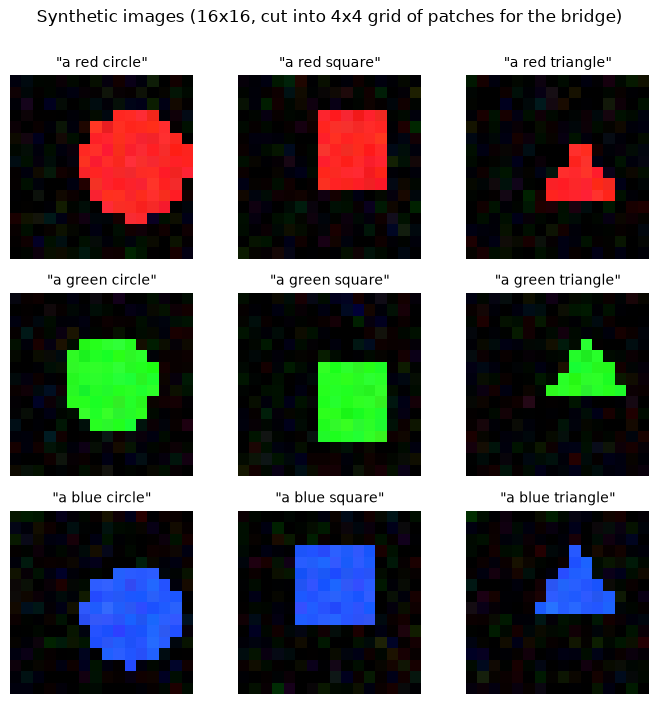

Text corpus example (LM pretraining, pure text):
   <bos> red circle <sep> a red circle <eos>
Vocab size: 10 | image patches: 16 x 48-dim


In [2]:
# 3种颜色 × 3种形状 = 9个视觉概念
COLORS = {'red': (1.0, 0.15, 0.15), 'green': (0.15, 1.0, 0.15), 'blue': (0.15, 0.35, 1.0)}
SHAPES = ['circle', 'square', 'triangle']
ALL_PAIRS = [(c, s) for c in COLORS for s in SHAPES]
IMG = 16  # 图像尺寸 16x16x3

def draw_image(color, shape, rng):
    """Draw one colored shape with position/size jitter and noise"""
    img = np.zeros((IMG, IMG, 3))
    img += rng.normal(0, 0.04, img.shape)  # background noise
    # 位置和大小随机抖动:迫使编码器学"概念"而不是死记像素位置
    cx, cy = rng.uniform(5.5, 10.5, 2)
    r = rng.uniform(3.0, 5.0)
    yy, xx = np.mgrid[0:IMG, 0:IMG]
    if shape == 'circle':
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
    elif shape == 'square':
        mask = (np.abs(xx - cx) <= r * 0.8) & (np.abs(yy - cy) <= r * 0.8)
    else:  # triangle
        mask = (yy - (cy - r) >= 0) & (yy - (cy - r) <= 1.5 * r) & \
               (np.abs(xx - cx) <= (yy - (cy - r)) / 1.5)
    img[mask] = COLORS[color]
    img += rng.normal(0, 0.03, img.shape)
    return np.clip(img, 0, 1)

def to_patches(imgs):
    """(B,16,16,3) -> (B,16,48): 4x4 grid of flattened 4x4x3 patches"""
    B = imgs.shape[0]
    # reshape+transpose把图像切成4x4网格的patch:桥需要的是patch序列而非单向量
    return imgs.reshape(B, 4, 4, 4, 4, 3).transpose(0, 1, 3, 2, 4, 5).reshape(B, 16, 48)

def make_images(n, rng):
    """Generate n images with class labels (0..8)"""
    X, y = [], []
    for _ in range(n):
        k = rng.integers(9)
        c, s = ALL_PAIRS[k]
        X.append(draw_image(c, s, rng))
        y.append(k)
    return np.array(X), np.array(y)

# 词表:10个token。<sep>分隔"上文提及"与"正式描述"
VOCAB = ['<bos>', '<eos>', '<sep>', 'a', 'red', 'green', 'blue', 'circle', 'square', 'triangle']
W2I = {w: i for i, w in enumerate(VOCAB)}
V = len(VOCAB)

def seq_ids(c, s):
    """Prompted caption: <bos> c s <sep> a c s <eos> (context mention -> description)"""
    return [W2I['<bos>'], W2I[c], W2I[s], W2I['<sep>'], W2I['a'], W2I[c], W2I[s], W2I['<eos>']]

# 可视化9个概念:图像及其(桥训练阶段才会配对的)标题
fig, axes = plt.subplots(3, 3, figsize=(7, 7))
for ax, (c, s) in zip(axes.flat, ALL_PAIRS):
    ax.imshow(draw_image(c, s, rng_demo))
    ax.set_title(f'"a {c} {s}"', fontsize=10)
    ax.axis('off')
plt.suptitle('Synthetic images (16x16, cut into 4x4 grid of patches for the bridge)', y=1.0)
plt.tight_layout()
plt.show()

print('Text corpus example (LM pretraining, pure text):')
print('  ', ' '.join(VOCAB[t] for t in seq_ids('red', 'circle')))
print(f'Vocab size: {V} | image patches: 16 x 48-dim')

## Stage 0a: Pretrain & Freeze the Image Encoder(预训练并冻结图像编码器)

#### 💻 代码解读

**做什么:** 用 9 类分类任务预训练一个小图像编码器(patch 级 MLP),然后**冻结**。它输出 16 个 patch 特征(16×32),对应 BLIP-2 里冻结 ViT 的 patch token。

**怎么做:**
- 编码器对每个 48 维 patch 独立做 两层 MLP(48→384→32,He 初始化配 ReLU),得到 (B,16,32) 的 patch 特征序列 F。
- 预训练目标:把 16 个 patch 特征**平均池化**后接线性分类头做 9 类分类——这只是给编码器灌入语义的代理任务,训练完分类头即丢弃,桥只使用 patch 级特征 F。
- 反向传播手写:交叉熵对 logits 的梯度 = `softmax − one-hot`;平均池化的梯度是把上游梯度均匀摊回 16 个 patch(除以 16);`np.einsum('bpi,bph->ih',...)` 同时对 batch 维和 patch 维求和,一步算出权重梯度。
- 训练 2500 步后测试准确率约 95.6%,随后编码器进入**冻结**状态——之后桥的训练中它只做前向,参数与梯度都不再更新。

[encoder] step 500: loss=0.4975  batch_acc=0.750


[encoder] step 1000: loss=0.1832  batch_acc=0.953


[encoder] step 1500: loss=0.1032  batch_acc=0.969


[encoder] step 2000: loss=0.0791  batch_acc=0.984


[encoder] step 2500: loss=0.0351  batch_acc=0.984
[encoder] TEST accuracy = 95.6%  -> encoder is now FROZEN


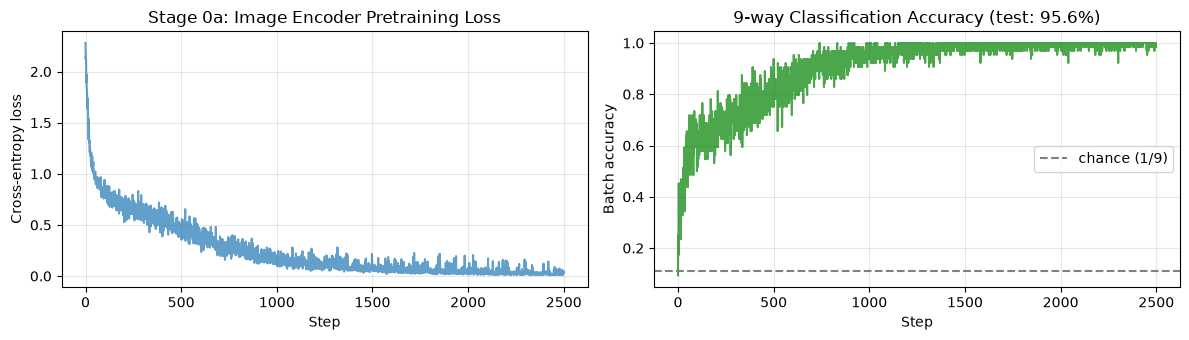

In [3]:
D_V = 32  # patch特征维度

# patch级编码器:每个48维patch独立过两层MLP(He初始化配ReLU)
enc = {'W1': rng.normal(0, np.sqrt(2 / 48), (48, 384)), 'b1': np.zeros(384),
       'W2': rng.normal(0, np.sqrt(2 / 384), (384, D_V)), 'b2': np.zeros(D_V)}
# 分类头只在预训练用,训练完丢弃(桥只用patch特征)
head = {'Wc': rng.normal(0, np.sqrt(2 / D_V), (D_V, 9)), 'bc': np.zeros(9)}

def enc_forward(P):
    """Patch encoder: (B,16,48) -> patch features (B,16,D_V)"""
    h_pre = P @ enc['W1'] + enc['b1']
    h = np.maximum(h_pre, 0)
    return h @ enc['W2'] + enc['b2'], (P, h_pre, h)

def softmax(L):
    # 数值稳定:减去每行最大值再exp,防止溢出
    L = L - L.max(-1, keepdims=True)
    e = np.exp(L)
    return e / e.sum(-1, keepdims=True)

def adam_update(p, g, m, v, t, lr, b1=0.9, b2=0.999, eps=1e-8):
    """Adam with bias correction"""
    for k in p:
        m[k] = b1 * m[k] + (1 - b1) * g[k]
        v[k] = b2 * v[k] + (1 - b2) * g[k] ** 2
        # 偏差修正:除以(1-beta^t),抵消动量初始化为0造成的低估
        p[k] -= lr * (m[k] / (1 - b1 ** t)) / (np.sqrt(v[k] / (1 - b2 ** t)) + eps)

Xtr, ytr = make_images(2000, rng)
Ptr = to_patches(Xtr)

me = {k: np.zeros_like(v) for k, v in enc.items()}; ve = {k: np.zeros_like(v) for k, v in enc.items()}
mh = {k: np.zeros_like(v) for k, v in head.items()}; vh = {k: np.zeros_like(v) for k, v in head.items()}
B = 64
enc_hist = []
for step in range(1, 2501):
    idx = rng.integers(0, len(Ptr), B)
    P, yb = Ptr[idx], ytr[idx]
    F, cache = enc_forward(P)
    pooled = F.mean(1)  # 平均池化16个patch -> (B,D_V),仅预训练代理任务使用
    logits = pooled @ head['Wc'] + head['bc']
    prob = softmax(logits)
    loss = -np.log(prob[np.arange(B), yb] + 1e-12).mean()
    acc = (logits.argmax(1) == yb).mean()
    # 交叉熵对logits的梯度 = softmax - one-hot
    dlog = (prob - np.eye(9)[yb]) / B
    gh = {'Wc': pooled.T @ dlog, 'bc': dlog.sum(0)}
    # 平均池化的梯度:均匀摊回16个patch(每个patch得1/16)
    dF = np.repeat((dlog @ head['Wc'].T)[:, None, :], 16, axis=1) / 16
    P_, h_pre, h = cache
    dh_pre = (dF @ enc['W2'].T) * (h_pre > 0)  # ReLU梯度:正区通过,负区截断
    # einsum同时对batch维b和patch维p求和,一步得到权重梯度
    ge = {'W1': np.einsum('bpi,bph->ih', P_, dh_pre), 'b1': dh_pre.sum((0, 1)),
          'W2': np.einsum('bph,bpd->hd', h, dF), 'b2': dF.sum((0, 1))}
    adam_update(enc, ge, me, ve, step, 2e-3)
    adam_update(head, gh, mh, vh, step, 2e-3)
    enc_hist.append((loss, acc))
    if step % 500 == 0:
        print(f'[encoder] step {step}: loss={loss:.4f}  batch_acc={acc:.3f}')

Xte, yte = make_images(500, rng)
Fte_all, _ = enc_forward(to_patches(Xte))
enc_acc = ((Fte_all.mean(1) @ head['Wc'] + head['bc']).argmax(1) == yte).mean()
print(f'[encoder] TEST accuracy = {enc_acc:.1%}  -> encoder is now FROZEN')

eh = np.array(enc_hist)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))
ax1.plot(eh[:, 0], alpha=0.7)
ax1.set_xlabel('Step'); ax1.set_ylabel('Cross-entropy loss')
ax1.set_title('Stage 0a: Image Encoder Pretraining Loss')
ax1.grid(True, alpha=0.3)
ax2.plot(eh[:, 1], alpha=0.7, color='green')
ax2.axhline(1 / 9, color='gray', ls='--', label='chance (1/9)')
ax2.set_xlabel('Step'); ax2.set_ylabel('Batch accuracy')
ax2.set_title(f'9-way Classification Accuracy (test: {enc_acc:.1%})')
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Stage 0b: Pretrain & Freeze the Language Model(预训练并冻结语言模型)

#### 💻 代码解读

**做什么:** 在**纯文本**语料(9 条 prompted caption)上预训练一个单层 tanh-RNN 自回归语言模型(手写 BPTT),然后**冻结**。

**怎么做:**
- RNN:`h_t = tanh(E[x_t]·Wxh + h_{t-1}·Whh + bh)`,`logits_t = h_t·Why + by`;教师强制(teacher forcing)训练:输入序列的前 7 个 token,预测后 7 个。
- 手写 BPTT:从最后一个时间步倒序回传,`dh` 累加"来自本步输出的梯度"与"来自下一步隐状态的梯度";tanh 的梯度是 `1−h²`;`np.add.at` 把嵌入梯度按 token id 散射累加(同一 token 出现多次时梯度要累加,普通花式索引赋值会丢失重复项)。
- **理论下限**:句式 `<bos> c s <sep> a c s <eos>` 的 7 个预测位置中,只有首次出现的颜色和形状各携带 ln3 的不可预测信息,其余 5 个位置(语法与复制)全部可确定 → 下限 = 2·ln3/7 ≈ 0.3139。训练损失精确收敛到该值,说明 LM 已把语料学到极限。
- 最后检验**复制通路**:给 LM 喂 9 条 prompt 的前半段,检查它是否能逐 token 正确续写描述部分——这条"根据上文条件生成"的通路就是桥将要借用的接口。

[LM] final loss = 0.3139   theoretical floor = 0.3139
[LM] conditioning-pathway check: given "c s <sep>", continues "a c s <eos>" correctly for 100% of 9 prompts  -> LM is now FROZEN


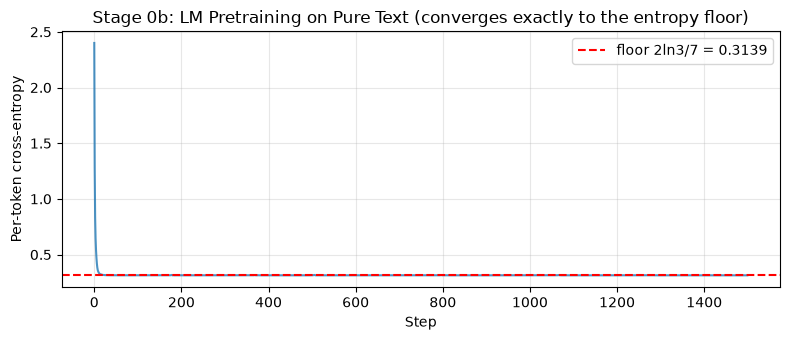

In [4]:
D_E = 32   # 词嵌入维度(桥的输出也落在这个空间)
D_H = 192  # RNN隐状态维度

lm = {'E': rng.normal(0, 0.5, (V, D_E)),                          # 词嵌入表
      'Wxh': rng.normal(0, np.sqrt(1 / D_E), (D_E, D_H)),
      'Whh': rng.normal(0, np.sqrt(1 / D_H), (D_H, D_H)),
      'bh': np.zeros(D_H),
      'Why': rng.normal(0, np.sqrt(1 / D_H), (D_H, V)),
      'by': np.zeros(V)}

SEQS = np.array([seq_ids(c, s) for c, s in ALL_PAIRS])  # (9,8) 全部语料

def rnn_forward(p, inp_emb):
    """Single-layer tanh RNN: (B,T,D_E) -> hidden states (B,T,D_H), logits (B,T,V)"""
    Bn, T, _ = inp_emb.shape
    h = np.zeros((Bn, D_H))
    hs = np.zeros((Bn, T, D_H))
    for t in range(T):
        # 经典RNN递归:输入嵌入与上一步隐状态共同决定本步隐状态
        h = np.tanh(inp_emb[:, t] @ p['Wxh'] + h @ p['Whh'] + p['bh'])
        hs[:, t] = h
    return hs, hs @ p['Why'] + p['by']

def rnn_pretrain(p, seqs, steps, lr=5e-3):
    """Teacher-forced LM pretraining with hand-written BPTT; returns loss history"""
    ml = {k: np.zeros_like(v) for k, v in p.items()}
    vl = {k: np.zeros_like(v) for k, v in p.items()}
    inp_ids, tgt_ids = seqs[:, :-1], seqs[:, 1:]
    hist = []
    Bn, T = tgt_ids.shape
    for step in range(1, steps + 1):
        emb = p['E'][inp_ids]                 # (9,T,D_E) 整个语料当一个batch
        hs, logits = rnn_forward(p, emb)
        prob = softmax(logits)
        loss = -np.log(prob[np.arange(Bn)[:, None], np.arange(T)[None, :], tgt_ids] + 1e-12).mean()
        dlog = prob.copy()
        dlog[np.arange(Bn)[:, None], np.arange(T)[None, :], tgt_ids] -= 1
        dlog /= (Bn * T)
        g = {k: np.zeros_like(v) for k, v in p.items()}
        g['Why'] = np.einsum('bth,btv->hv', hs, dlog)
        g['by'] = dlog.sum((0, 1))
        # BPTT:从最后时刻倒序回传;dh = 本步输出梯度 + 下一步隐状态传回的梯度
        dh_next = np.zeros((Bn, D_H))
        demb = np.zeros_like(emb)
        for t in range(T - 1, -1, -1):
            dh = dlog[:, t] @ p['Why'].T + dh_next
            dh_pre = dh * (1 - hs[:, t] ** 2)  # tanh梯度:1-h^2
            h_prev = hs[:, t - 1] if t > 0 else np.zeros((Bn, D_H))
            g['Wxh'] += emb[:, t].T @ dh_pre
            g['Whh'] += h_prev.T @ dh_pre
            g['bh'] += dh_pre.sum(0)
            demb[:, t] = dh_pre @ p['Wxh'].T
            dh_next = dh_pre @ p['Whh'].T
        # np.add.at按token id散射累加:同一token多次出现时梯度正确累加
        np.add.at(g['E'], inp_ids, demb)
        adam_update(p, g, ml, vl, step, lr)
        hist.append(loss)
    return hist

lm_hist = rnn_pretrain(lm, SEQS, 1500)
floor = 2 * np.log(3) / 7  # 理论下限:7个预测位置中只有颜色和形状首现各携带ln3信息
print(f'[LM] final loss = {lm_hist[-1]:.4f}   theoretical floor = {floor:.4f}')

# 复制通路检验:教师强制下,<sep>之后4个位置(a,c,s,<eos>)是否全部预测正确
_, lg_all = rnn_forward(lm, lm['E'][SEQS[:, :-1]])
copy_acc = (lg_all[:, 3:7].argmax(-1) == SEQS[:, 4:8]).mean()
print(f'[LM] conditioning-pathway check: given "c s <sep>", continues "a c s <eos>" '
      f'correctly for {copy_acc:.0%} of 9 prompts  -> LM is now FROZEN')

plt.figure(figsize=(8, 3.5))
plt.plot(lm_hist, alpha=0.8)
plt.axhline(floor, color='red', ls='--', label=f'floor 2ln3/7 = {floor:.4f}')
plt.xlabel('Step'); plt.ylabel('Per-token cross-entropy')
plt.title('Stage 0b: LM Pretraining on Pure Text (converges exactly to the entropy floor)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## The Bridge: a Mini Q-Former with a Tanh Gate(桥:带 tanh 门控的迷你 Q-Former)

#### 💻 代码解读

**做什么:** 定义桥——本实验**唯一可训练**的模块:K=2 个可学习 query 对 16 个冻结 patch 特征做 cross-attention,经小 MLP 投影到 LM 的词嵌入空间,乘以 tanh(g) 门控后作为视觉前缀;并画出参数量对比图。

**怎么做:**
- **Q-Former 精髓**:`q`(K×32)是与输入无关的可学习向量,扮演"提问者":`scores = q·(F·Wk)ᵀ/√d` 对每个 patch 打分,softmax 后加权汇聚 `F·Wv`——把任意多个 patch 压缩成**固定 K 个**视觉 token(真实 BLIP-2 用 32 个 query 从 257 个 ViT token 中提取)。
- 注意力输出再过一个两层 MLP(32→32→32)投影进 LM 嵌入空间——桥必须把"视觉方言"翻译成冻结 LM 听得懂的"词嵌入语言"。
- **Flamingo 门控**:`prefix = tanh(g)·U`,标量 g **初始化为 0** → 训练开始时前缀恒为零向量,输出不携带任何图像信息(与 Flamingo 门在残差分支上、g=0 时逐位恒等不同,这里零前缀仍占据两个时间步,是门控位置上的简化)。注意由链式法则,g=0 时 ∂L/∂U = tanh(g)·∂L/∂prefix = 0,即注意力与 MLP 参数暂时收不到梯度,只有 ∂L/∂g = Σ(∂L/∂prefix ⊙ U)·(1−tanh²g) 非零——训练必然呈现"门先开、内容后学"的顺序(训练曲线将验证)。
- 参数量:桥 4,225 vs 双塔 76,586(编码器 31,136 + LM 45,450),桥只占 **5.5%**——与真实 BLIP-2 (188M 可训练 / 数十亿冻结) 的比例同一量级。
- **相对真实 Q-Former 的简化声明**:真实 Q-Former 是 BERT 式模块——query 之间还有自注意力、与文本共享部分层,且 BLIP-2 先用 ITC/ITM/ITG 三目标做第一阶段表征学习、再接生成式第二阶段;本实现省略这些,只保留"可学习 query + cross-attention"这一最小核心,直接用 caption 损失端到端训桥。

Image encoder (FROZEN): 31,136 params
Language model (FROZEN): 45,450 params
Bridge      (TRAINABLE): 4,225 params  = 5.5% of the two towers


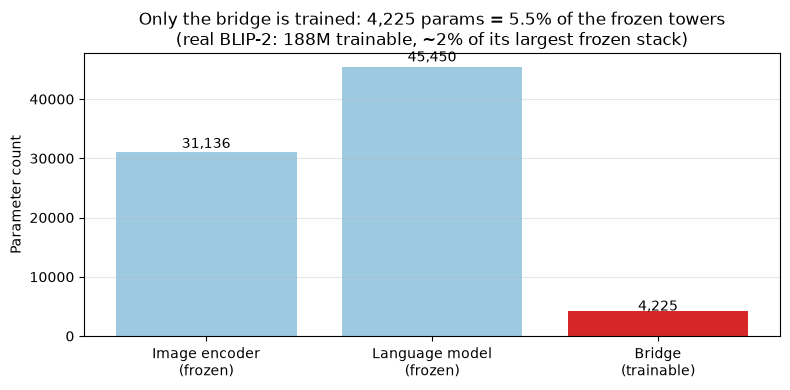

In [5]:
K = 2    # 可学习query数量(BLIP-2用32个;本玩具任务2个足够)
D_A = 32  # 注意力空间维度
D_M = 32  # 投影MLP隐层维度

bridge = {
    # K个可学习query:与输入无关的"提问者",负责从patch特征中提取信息
    'q': rng.normal(0, 0.5, (K, D_A)),
    'Wk': rng.normal(0, np.sqrt(1 / D_V), (D_V, D_A)),   # patch特征 -> key
    'Wv': rng.normal(0, np.sqrt(1 / D_V), (D_V, D_A)),   # patch特征 -> value
    'Wm': rng.normal(0, np.sqrt(2 / D_A), (D_A, D_M)), 'bm': np.zeros(D_M),
    'Wo': rng.normal(0, np.sqrt(1 / D_M), (D_M, D_E)), 'bo': np.zeros(D_E),
    # Flamingo门控:标量g初始化为0 -> tanh(0)=0,训练开始时桥输出恒为零
    'g': np.zeros(1),
}

def bridge_forward(br, F):
    """Cross-attention of K learnable queries over patch features, tanh-gated.
    F (B,16,D_V) -> prefix (B,K,D_E)"""
    Kf = F @ br['Wk']                                     # (B,16,D_A)
    Vf = F @ br['Wv']                                     # (B,16,D_A)
    # 注意力分数:每个query对16个patch打分;除以sqrt(d)防止点积过大压扁softmax
    scores = np.einsum('kd,bpd->bkp', br['q'], Kf) / np.sqrt(D_A)
    A = softmax(scores)                                   # (B,K,16) 注意力权重
    out = np.einsum('bkp,bpd->bkd', A, Vf)                # 加权汇聚 (B,K,D_A)
    m_pre = out @ br['Wm'] + br['bm']
    mh = np.maximum(m_pre, 0)
    U = mh @ br['Wo'] + br['bo']                          # 翻译到LM嵌入空间 (B,K,D_E)
    gate = np.tanh(br['g'][0])
    # Flamingo式门控:g=0时前缀为零向量,LM完全不受桥的干扰
    return gate * U, (F, Kf, Vf, A, out, m_pre, mh, U, gate)

def bridge_backward(br, cache, dprefix):
    """Manual backprop through gate, projection MLP, and cross-attention"""
    F, Kf, Vf, A, out, m_pre, mh, U, gate = cache
    g = {}
    # 门控的梯度:dU被tanh(g)缩放(g=0时为0!),而g自身的梯度始终存在
    dU = gate * dprefix
    g['g'] = np.array([np.sum(dprefix * U) * (1 - gate ** 2)])
    g['Wo'] = np.einsum('bkm,bke->me', mh, dU); g['bo'] = dU.sum((0, 1))
    dm_pre = (dU @ br['Wo'].T) * (m_pre > 0)
    g['Wm'] = np.einsum('bkd,bkm->dm', out, dm_pre); g['bm'] = dm_pre.sum((0, 1))
    dout = dm_pre @ br['Wm'].T
    dVf = np.einsum('bkp,bkd->bpd', A, dout)
    dA = np.einsum('bkd,bpd->bkp', dout, Vf)
    # softmax的雅可比:dS = A*(dA - sum(dA*A)),即"减去加权平均"再缩放
    dS = A * (dA - (dA * A).sum(-1, keepdims=True)) / np.sqrt(D_A)
    g['q'] = np.einsum('bkp,bpd->kd', dS, Kf)
    dKf = np.einsum('bkp,kd->bpd', dS, br['q'])
    g['Wk'] = np.einsum('bpi,bpd->id', F, dKf)
    g['Wv'] = np.einsum('bpi,bpd->id', F, dVf)
    return g

n_enc = sum(v.size for v in enc.values())
n_lm = sum(v.size for v in lm.values())
n_br = sum(v.size for v in bridge.values())
pct = 100 * n_br / (n_enc + n_lm)
print(f'Image encoder (FROZEN): {n_enc:,} params')
print(f'Language model (FROZEN): {n_lm:,} params')
print(f'Bridge      (TRAINABLE): {n_br:,} params  = {pct:.1f}% of the two towers')

plt.figure(figsize=(8, 4))
names = ['Image encoder\n(frozen)', 'Language model\n(frozen)', 'Bridge\n(trainable)']
vals = [n_enc, n_lm, n_br]
bars = plt.bar(names, vals, color=['#9ecae1', '#9ecae1', '#d62728'])
for b, v in zip(bars, vals):
    plt.text(b.get_x() + b.get_width() / 2, v * 1.02, f'{v:,}', ha='center', fontsize=10)
plt.ylabel('Parameter count')
plt.title(f'Only the bridge is trained: {n_br:,} params = {pct:.1f}% of the frozen towers\n'
          f'(real BLIP-2: 188M trainable, ~2% of its largest frozen stack)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## Plugging the Bridge into the Frozen LM(把桥插进冻结 LM:梯度穿过但参数不动)

#### 💻 代码解读

**做什么:** 定义桥+冻结 LM 的联合前向/反向,以及逐 token 的贪心生成;并在**训练前**评估:此时 gate=0,LM 的输出应与图像完全无关。

**怎么做:**
- 输入序列拼装:`[emb(<bos>), prefix₁, prefix₂, emb(<sep>), emb(a), emb(c), emb(s)]`——视觉前缀恰好放在文本预训练中"上文提及"的位置,`<sep>` 之后 LM 按已学会的条件通路续写描述;损失只算 `<sep>` 之后 4 个位置(a, c, s, `<eos>`)。
- **本实验最重要的一段代码**:反向传播时,梯度从这 4 个位置出发,沿 BPTT **穿过冻结 RNN 的每一步**(经过 `Why`、`Whh`、`Wxh`)一路回传到前缀位置,再进入桥——`dinp[:, 1:1+K]` 就是穿过整个冻结 LM 后落在前缀上的梯度。**冻结 ≠ 梯度不流过**:我们用 LM 的参数计算梯度,但从不更新它们(注意代码里没有任何对 `lm` 的 `adam_update`)。
- `generate`:推理时逐 token 贪心生成——先喂 `<bos>` 和视觉前缀,再从 `<sep>` 开始自回归:每步取 argmax token,查它的**冻结**词嵌入喂回下一步。
- 训练前评估:500 张不同图像只产生 **1 种**标题(gate=0 ⇒ 前缀恒为零 ⇒ 输出与图像无关),准确率≈10%(纯属撞对该类)。

In [6]:
def bridged_grads(br, lmp, F, cap):
    """Forward+backward of bridge -> frozen LM. Returns loss and BRIDGE grads only.
    Input layout: [<bos>, prefix_1..K, <sep>, a, c, s] -> predict [a, c, s, <eos>]"""
    Bn = F.shape[0]
    prefix, bc = bridge_forward(br, F)
    # 视觉前缀放在文本语料"上文提及"的位置:桥借用LM已学会的条件生成通路
    e_bos = np.repeat(lmp['E'][W2I['<bos>']][None, None], Bn, 0)
    e_sep = np.repeat(lmp['E'][W2I['<sep>']][None, None], Bn, 0)
    txt = lmp['E'][cap[:, 4:7]]                    # a, c, s 的词嵌入(教师强制输入)
    inp = np.concatenate([e_bos, prefix, e_sep, txt], axis=1)   # (B,7,D_E)
    hs, logits = rnn_forward(lmp, inp)
    tgt = cap[:, 4:8]                              # 目标:a c s <eos>
    lg = logits[:, 3:7]                            # 只在<sep>之后的4个位置计损失
    prob = softmax(lg)
    loss = -np.log(prob[np.arange(Bn)[:, None], np.arange(4)[None, :], tgt] + 1e-12).mean()
    dlg = prob.copy()
    dlg[np.arange(Bn)[:, None], np.arange(4)[None, :], tgt] -= 1
    dlg /= (Bn * 4)
    dlog_full = np.zeros_like(logits)
    dlog_full[:, 3:7] = dlg
    # ★ 核心:BPTT穿过整个冻结LM ——用冻结参数计算梯度,但绝不更新它们
    dh_next = np.zeros((Bn, D_H))
    dinp = np.zeros_like(inp)
    for t in range(6, -1, -1):
        dh = dlog_full[:, t] @ lmp['Why'].T + dh_next
        dh_pre = dh * (1 - hs[:, t] ** 2)
        dinp[:, t] = dh_pre @ lmp['Wxh'].T         # 梯度"穿过"冻结的输入投影
        dh_next = dh_pre @ lmp['Whh'].T            # 梯度"穿过"冻结的递归矩阵
    # 只取落在前缀位置(1..K)的梯度传给桥;LM参数没有任何更新
    return loss, bridge_backward(br, bc, dinp[:, 1:1 + K])

def generate(br, lmp, F, max_len=5):
    """Token-by-token greedy generation from the frozen LM, conditioned via the bridge"""
    prefix, _ = bridge_forward(br, F)
    Bn = F.shape[0]
    h = np.zeros((Bn, D_H))
    # 先喂<bos>与K个视觉前缀(它们不是真实token,直接以嵌入形式输入)
    h = np.tanh(np.repeat(lmp['E'][W2I['<bos>']][None], Bn, 0) @ lmp['Wxh'] + h @ lmp['Whh'] + lmp['bh'])
    for t in range(K):
        h = np.tanh(prefix[:, t] @ lmp['Wxh'] + h @ lmp['Whh'] + lmp['bh'])
    # 从<sep>开始逐token贪心自回归:argmax -> 查冻结词嵌入 -> 喂回下一步
    tok = np.full(Bn, W2I['<sep>'])
    outs = []
    for _ in range(max_len):
        h = np.tanh(lmp['E'][tok] @ lmp['Wxh'] + h @ lmp['Whh'] + lmp['bh'])
        tok = (h @ lmp['Why'] + lmp['by']).argmax(1)
        outs.append(tok.copy())
    return np.array(outs).T                        # (B,max_len)

def caption_acc(br, lmp, F, y):
    """Exact-match caption accuracy: generated 'a c s <eos>' vs ground truth"""
    gen = generate(br, lmp, F)
    want = np.array([[W2I['a'], W2I[ALL_PAIRS[k][0]], W2I[ALL_PAIRS[k][1]], W2I['<eos>']] for k in y])
    return (gen[:, :4] == want).all(1).mean(), gen

cap_te = np.array([seq_ids(*ALL_PAIRS[k]) for k in yte])
Ftr_all, _ = enc_forward(Ptr)                      # 冻结编码器:特征可一次性预计算
cap_tr = np.array([seq_ids(*ALL_PAIRS[k]) for k in ytr])

acc_before, gen_before = caption_acc(bridge, lm, Fte_all, yte)
distinct = len(set(tuple(r) for r in gen_before))
loss_before, _ = bridged_grads(bridge, lm, Fte_all, cap_te)
print(f'BEFORE bridge training (gate = tanh(0) = 0):')
print(f'  caption accuracy = {acc_before:.1%}   (chance = 1/9 = 11.1%)')
print(f'  distinct captions across 500 different images = {distinct}  -> output ignores the image!')
print(f'  the one caption it always generates: '
      f'"{" ".join(VOCAB[t] for t in gen_before[0, :4])}"')
print(f'  loss = {loss_before:.4f}')

BEFORE bridge training (gate = tanh(0) = 0):
  caption accuracy = 10.0%   (chance = 1/9 = 11.1%)
  distinct captions across 500 different images = 1  -> output ignores the image!
  the one caption it always generates: "a red triangle <eos>"
  loss = 1.4037


## Training the Bridge(训练桥:两塔纹丝不动)

#### 💻 代码解读

**做什么:** 训练桥 3000 步(只更新 4,225 个参数),记录损失、gate 开度与标题准确率的演化;训练后**逐参数验证**两座冻结塔没有发生任何改变。

**怎么做:**
- 训练开始前用 `deepcopy` 给冻结 LM 和编码器拍快照;每步:冻结特征 → 桥前向 → 冻结 LM 前向 → 损失 → 梯度穿过冻结 LM 回到桥 → **只对桥做 Adam 更新**。
- 每 100 步在 200 张测试图上做一次贪心生成评估,画出准确率上升曲线。
- 左图:桥训练损失从纯文本水平(≈0.55 以上)降到 ≈0.03(批次最低 ≈0.003),**跌破**了纯文本 LM 在这 4 个位置的理论下限 2·ln3/4≈0.549——下限被突破不是因为 LM 变了(它冻结着),而是缺失的信息(≈ln9 nats/图)由图像经桥注入。
- 中图:gate 开度 |tanh(g)| 从 0 缓慢爬升——正如代码解读所述,起步阶段只有 g 有梯度,注意力参数要等门开出缝隙后才开始学习;最终门只开到 ≈0.1 就足够了(前缀的模长由 U 自适应补偿)。
- 结束后打印两座塔的最大参数漂移:必须精确为 0.0。

step 500: loss=0.0053  gate=+0.098  caption_acc=98.5%


step 1000: loss=0.0451  gate=+0.110  caption_acc=95.0%


step 1500: loss=0.0328  gate=+0.117  caption_acc=96.0%


step 2000: loss=0.0042  gate=+0.107  caption_acc=96.5%


step 2500: loss=0.0028  gate=+0.113  caption_acc=97.0%


step 3000: loss=0.0084  gate=+0.100  caption_acc=95.5%

max parameter drift -- LM: 0.0, encoder: 0.0
gradients FLOWED THROUGH the frozen LM every step, yet its parameters never moved.


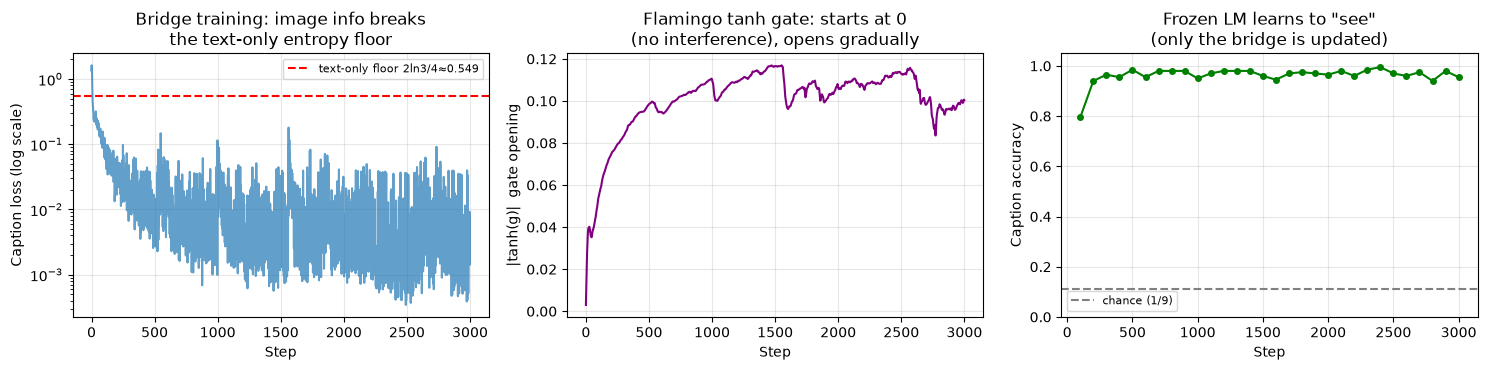

In [7]:
# 冻结快照:训练结束后逐参数验证两座塔纹丝不动
lm_snapshot = deepcopy(lm)
enc_snapshot = deepcopy(enc)

mb = {k: np.zeros_like(v) for k, v in bridge.items()}
vb = {k: np.zeros_like(v) for k, v in bridge.items()}
hist_loss, hist_gate, acc_steps, acc_vals = [], [], [], []

for step in range(1, 3001):
    idx = rng.integers(0, len(Ftr_all), B)
    loss, gb = bridged_grads(bridge, lm, Ftr_all[idx], cap_tr[idx])
    adam_update(bridge, gb, mb, vb, step, 3e-3)    # ← 唯一的参数更新:只有桥!
    hist_loss.append(loss)
    hist_gate.append(np.tanh(bridge['g'][0]))
    if step % 100 == 0:
        a, _ = caption_acc(bridge, lm, Fte_all[:200], yte[:200])
        acc_steps.append(step); acc_vals.append(a)
    if step % 500 == 0:
        print(f'step {step}: loss={loss:.4f}  gate={np.tanh(bridge["g"][0]):+.3f}  caption_acc={acc_vals[-1]:.1%}')

# 验证冻结:两座塔的每个参数与训练前快照逐位比较
drift_lm = max(np.abs(lm[k] - lm_snapshot[k]).max() for k in lm)
drift_enc = max(np.abs(enc[k] - enc_snapshot[k]).max() for k in enc)
print(f'\nmax parameter drift -- LM: {drift_lm}, encoder: {drift_enc}')
print('gradients FLOWED THROUGH the frozen LM every step, yet its parameters never moved.')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 3.8))
ax1.plot(hist_loss, alpha=0.7)
ax1.axhline(2 * np.log(3) / 4, color='red', ls='--', label='text-only floor 2ln3/4≈0.549')
ax1.set_yscale('log')
ax1.set_xlabel('Step'); ax1.set_ylabel('Caption loss (log scale)')
ax1.set_title('Bridge training: image info breaks\nthe text-only entropy floor')
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)
ax2.plot(np.abs(hist_gate), color='purple')
ax2.set_xlabel('Step'); ax2.set_ylabel('|tanh(g)|  gate opening')
ax2.set_title('Flamingo tanh gate: starts at 0\n(no interference), opens gradually')
ax2.grid(True, alpha=0.3)
ax3.plot(acc_steps, acc_vals, 'o-', color='green', ms=4)
ax3.axhline(1 / 9, color='gray', ls='--', label='chance (1/9)')
ax3.set_xlabel('Step'); ax3.set_ylabel('Caption accuracy')
ax3.set_title('Frozen LM learns to "see"\n(only the bridge is updated)')
ax3.set_ylim(0, 1.05); ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Results: the Frozen LM Now Captions Images(结果:冻结 LM 学会了看图说话)

#### 💻 代码解读

**做什么:** 训练后评估 500 张新图像的标题准确率,展示逐 token 的生成过程,并画出"训练前 vs 训练后"的生成对比图。

**怎么做:**
- 整体准确率(严格逐 token 匹配 `a c s <eos>`)约 95%,对比训练前 10%(且与图像无关)。
- 打印 3 张图的逐 token 生成轨迹:每一步冻结 LM 输出的 token——这就是"图像 → 桥 → 前缀 → 冻结 LM 自回归"的完整链路。
- 对比图:8 张测试图,下方灰字是训练前生成(所有图一样),标题是训练后生成(绿=正确,红=错误)。

AFTER bridge training:
  caption accuracy on 500 unseen images = 95.2%  (before: 10.0%)
  caption loss = 0.0307  (before: 1.4037)
  final gate tanh(g) = +0.1004

Token-by-token generation (frozen LM, conditioned via 2 visual prefix embeddings):
  image #0 (true: red square):  <bos> [vis_1] [vis_2] <sep> -> a -> red -> square -> <eos>   CORRECT
  image #1 (true: red circle):  <bos> [vis_1] [vis_2] <sep> -> a -> red -> circle -> <eos>   CORRECT
  image #2 (true: green square):  <bos> [vis_1] [vis_2] <sep> -> a -> green -> square -> <eos>   CORRECT


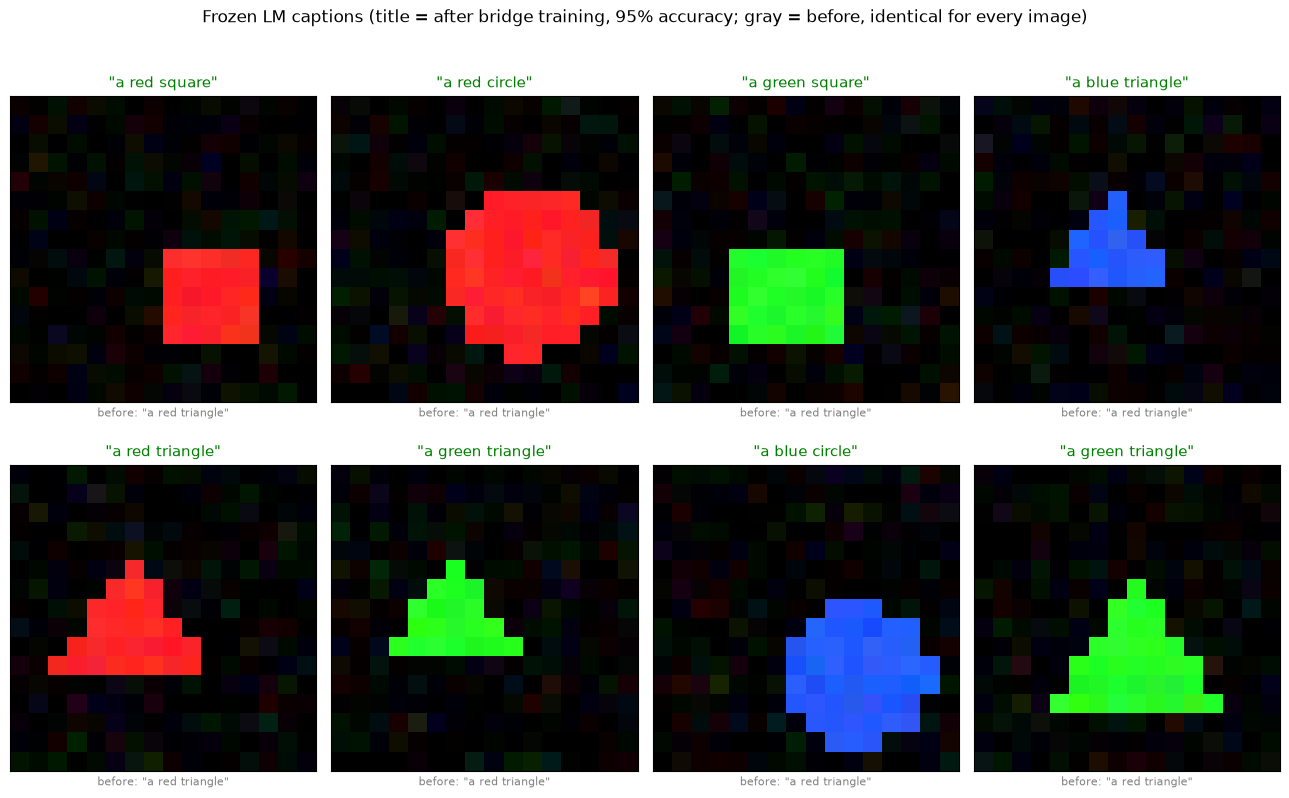

In [8]:
acc_after, gen_after = caption_acc(bridge, lm, Fte_all, yte)
loss_after, _ = bridged_grads(bridge, lm, Fte_all, cap_te)
print(f'AFTER bridge training:')
print(f'  caption accuracy on 500 unseen images = {acc_after:.1%}  (before: {acc_before:.1%})')
print(f'  caption loss = {loss_after:.4f}  (before: {loss_before:.4f})')
print(f'  final gate tanh(g) = {np.tanh(bridge["g"][0]):+.4f}\n')

# 逐token生成演示:冻结LM一步一步"说"出标题
print('Token-by-token generation (frozen LM, conditioned via 2 visual prefix embeddings):')
for i in range(3):
    c, s = ALL_PAIRS[yte[i]]
    toks = [VOCAB[t] for t in gen_after[i]]
    print(f'  image #{i} (true: {c} {s}):  <bos> [vis_1] [vis_2] <sep> -> ' +
          ' -> '.join(toks[:4]) + f'   {"CORRECT" if toks[:4] == ["a", c, s, "<eos>"] else "WRONG"}')

fig, axes = plt.subplots(2, 4, figsize=(13, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(Xte[i])
    c, s = ALL_PAIRS[yte[i]]
    after = ' '.join(VOCAB[t] for t in gen_after[i, :3])
    before = ' '.join(VOCAB[t] for t in gen_before[i, :3])
    ok = list(gen_after[i, :4]) == [W2I['a'], W2I[c], W2I[s], W2I['<eos>']]
    ax.set_title(f'"{after}"', fontsize=11, color=('green' if ok else 'red'))
    ax.set_xlabel(f'before: "{before}"', fontsize=8, color='gray')
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f'Frozen LM captions (title = after bridge training, {acc_after:.0%} accuracy; '
             f'gray = before, identical for every image)', y=0.99)
# h_pad拉开两行间距,防止上行的灰色"before"标签与下行的绿色标题重叠
plt.tight_layout(rect=[0, 0, 1, 0.96], h_pad=4.0); plt.show()

## Inside the Bridge: What Do the Queries Look At?(桥的内部:query 在看哪里)

#### 💻 代码解读

**做什么:** 可视化 Q-Former 机制的核心——每个可学习 query 对 16 个图像 patch 的注意力分布。

**怎么做:**
- 取 3 张测试图,前向桥拿到注意力矩阵 A(形状 B×K×16),把每个 query 的 16 个权重 reshape 成 4×4 网格画热力图。
- 可以看到 query 的注意力随图像内容变化:一个 query 分布较平、近似全局汇聚(类似平均池化),另一个聚焦在图形边缘的显著 patch 上——query 是"主动提问者",从冻结特征中按需提取信息(BLIP-2 用 32 个 query 从 257 个 ViT patch token 中提取信息)。

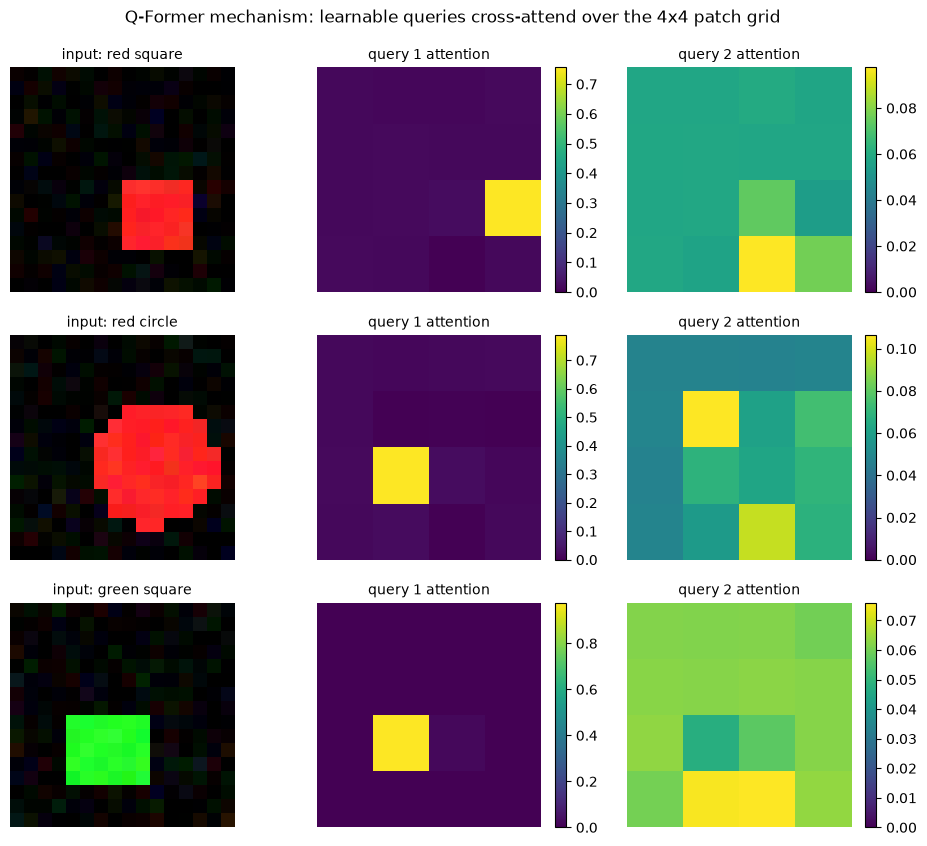

In [9]:
fig, axes = plt.subplots(3, K + 1, figsize=(3.2 * (K + 1), 8.5))
for row in range(3):
    F1 = Fte_all[row:row + 1]
    _, (_, _, _, A, *_ ) = bridge_forward(bridge, F1)   # A: (1,K,16) 注意力权重
    c, s = ALL_PAIRS[yte[row]]
    axes[row, 0].imshow(Xte[row])
    axes[row, 0].set_title(f'input: {c} {s}', fontsize=10)
    axes[row, 0].axis('off')
    for k in range(K):
        # 16个patch权重reshape回4x4空间网格
        m = axes[row, k + 1].imshow(A[0, k].reshape(4, 4), cmap='viridis', vmin=0)
        axes[row, k + 1].set_title(f'query {k + 1} attention', fontsize=10)
        axes[row, k + 1].axis('off')
        plt.colorbar(m, ax=axes[row, k + 1], fraction=0.046)
plt.suptitle('Q-Former mechanism: learnable queries cross-attend over the 4x4 patch grid', y=0.99)
plt.tight_layout(); plt.show()

## Ablation: the Bridge Can Only Unlock What the LM Already Knows(消融:桥只能解锁冻结 LM 已有的能力)

#### 💻 代码解读

**做什么:** 关键消融——把**同样架构的桥**接到一个只见过 `"a red circle"` 式短句(**没有**条件结构)的冻结 LM 上,同样训练 3000 步,对比标题准确率。

**怎么做:**
- LM-A 与主实验的 LM 架构、大小、训练步数完全相同,唯一区别是语料:`<bos> a c s <eos>`(纯标题,没有"上文提及→后文描述"的结构)。它同样精确收敛到自己的下限 2·ln3/4≈0.549。
- 关键在于:这个 LM 从不需要**跨步记住内容**——颜色、形状在语料中都不可由上文预测,于是它的递归矩阵 Whh 没学过"携带上文信息"的通路,前缀信息在递归中被冲刷掉。
- 桥以 soft-prompt 形式插在 `<bos>` 之前(`[prefix₁, prefix₂, <bos>, a, c, s]`),训练代码与主实验一致。
- 结果:同样的桥、同样的冻结编码器、同样的步数,标题准确率只有 ~50-60%(主实验 95%+)。**桥不能创造冻结 LM 没有的条件生成通路,只能借用已有的**——这就是 BLIP-2 强调"冻结 LLM 的质量决定多模态上限"的微缩版证据。

[LM-A] final loss = 0.5494  (its own floor 2ln3/4 = 0.5493)  -> FROZEN


[bridge->LM-A] step 1000: loss=0.3450  gate=-0.223


[bridge->LM-A] step 2000: loss=0.3396  gate=-0.304


[bridge->LM-A] step 3000: loss=0.3248  gate=-0.406

Same bridge, same encoder, same 3000 steps:
  bridge -> LM-A (captions-only corpus, no conditioning pathway): 54.2%
  bridge -> LM   (corpus with "mention -> describe" structure):   95.2%


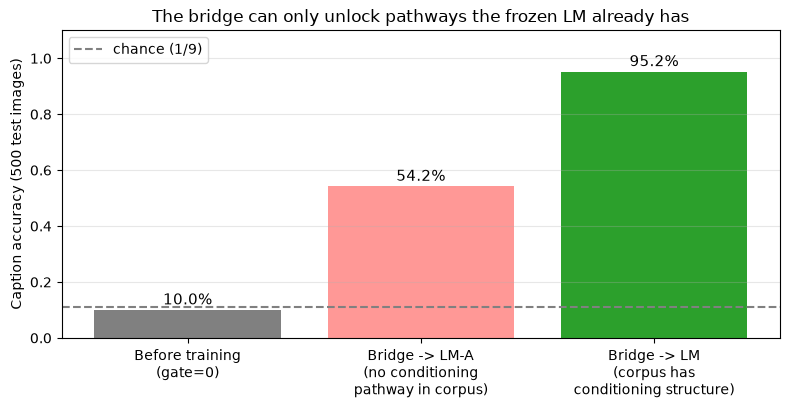

In [10]:
# LM-A:同架构同大小,但语料没有条件结构(<bos> a c s <eos>)
lmA = {'E': rng.normal(0, 0.5, (V, D_E)),
       'Wxh': rng.normal(0, np.sqrt(1 / D_E), (D_E, D_H)),
       'Whh': rng.normal(0, np.sqrt(1 / D_H), (D_H, D_H)),
       'bh': np.zeros(D_H),
       'Why': rng.normal(0, np.sqrt(1 / D_H), (D_H, V)),
       'by': np.zeros(V)}
SEQS_A = np.array([[W2I['<bos>'], W2I['a'], W2I[c], W2I[s], W2I['<eos>']] for c, s in ALL_PAIRS])
histA = rnn_pretrain(lmA, SEQS_A, 1500)
print(f'[LM-A] final loss = {histA[-1]:.4f}  (its own floor 2ln3/4 = {2 * np.log(3) / 4:.4f})  -> FROZEN')

# 同样架构的桥,重新初始化,接到LM-A上
bridgeA = {'q': rng.normal(0, 0.5, (K, D_A)),
           'Wk': rng.normal(0, np.sqrt(1 / D_V), (D_V, D_A)),
           'Wv': rng.normal(0, np.sqrt(1 / D_V), (D_V, D_A)),
           'Wm': rng.normal(0, np.sqrt(2 / D_A), (D_A, D_M)), 'bm': np.zeros(D_M),
           'Wo': rng.normal(0, np.sqrt(1 / D_M), (D_M, D_E)), 'bo': np.zeros(D_E),
           'g': np.zeros(1)}

def bridgedA_grads(br, lmp, F, cap):
    """Same bridge training, but prefix goes BEFORE <bos> (soft prompt) for LM-A"""
    Bn = F.shape[0]
    prefix, bc = bridge_forward(br, F)
    inp = np.concatenate([prefix, lmp['E'][cap[:, :4]]], axis=1)   # [p1,p2,<bos>,a,c,s]
    hs, logits = rnn_forward(lmp, inp)
    tgt = cap[:, 1:]
    lg = logits[:, K:]
    prob = softmax(lg)
    loss = -np.log(prob[np.arange(Bn)[:, None], np.arange(4)[None, :], tgt] + 1e-12).mean()
    dlg = prob.copy()
    dlg[np.arange(Bn)[:, None], np.arange(4)[None, :], tgt] -= 1
    dlg /= (Bn * 4)
    dlog_full = np.zeros_like(logits); dlog_full[:, K:] = dlg
    dh_next = np.zeros((Bn, D_H)); dinp = np.zeros_like(inp)
    for t in range(K + 3, -1, -1):                 # 梯度同样穿过冻结的LM-A
        dh = dlog_full[:, t] @ lmp['Why'].T + dh_next
        dh_pre = dh * (1 - hs[:, t] ** 2)
        dinp[:, t] = dh_pre @ lmp['Wxh'].T
        dh_next = dh_pre @ lmp['Whh'].T
    return loss, bridge_backward(br, bc, dinp[:, :K])

capA_tr = np.array([[W2I['<bos>'], W2I['a'], W2I[ALL_PAIRS[k][0]], W2I[ALL_PAIRS[k][1]], W2I['<eos>']] for k in ytr])
mbA = {k: np.zeros_like(v) for k, v in bridgeA.items()}
vbA = {k: np.zeros_like(v) for k, v in bridgeA.items()}
for step in range(1, 3001):
    idx = rng.integers(0, len(Ftr_all), B)
    lossA, gbA = bridgedA_grads(bridgeA, lmA, Ftr_all[idx], capA_tr[idx])
    adam_update(bridgeA, gbA, mbA, vbA, step, 3e-3)
    if step % 1000 == 0:
        print(f'[bridge->LM-A] step {step}: loss={lossA:.4f}  gate={np.tanh(bridgeA["g"][0]):+.3f}')

# LM-A的生成:前缀在<bos>之前
prefixA, _ = bridge_forward(bridgeA, Fte_all)
Bn = len(Fte_all)
hA = np.zeros((Bn, D_H))
for t in range(K):
    hA = np.tanh(prefixA[:, t] @ lmA['Wxh'] + hA @ lmA['Whh'] + lmA['bh'])
tok = np.full(Bn, W2I['<bos>'])
outs = []
for _ in range(4):
    hA = np.tanh(lmA['E'][tok] @ lmA['Wxh'] + hA @ lmA['Whh'] + lmA['bh'])
    tok = (hA @ lmA['Why'] + lmA['by']).argmax(1)
    outs.append(tok.copy())
genA = np.array(outs).T
wantA = np.array([[W2I['a'], W2I[ALL_PAIRS[k][0]], W2I[ALL_PAIRS[k][1]], W2I['<eos>']] for k in yte])
accA = (genA == wantA).all(1).mean()
print(f'\nSame bridge, same encoder, same 3000 steps:')
print(f'  bridge -> LM-A (captions-only corpus, no conditioning pathway): {accA:.1%}')
print(f'  bridge -> LM   (corpus with "mention -> describe" structure):   {acc_after:.1%}')

plt.figure(figsize=(8, 4.2))
labels = ['Before training\n(gate=0)', 'Bridge -> LM-A\n(no conditioning\npathway in corpus)',
          'Bridge -> LM\n(corpus has\nconditioning structure)']
vals = [acc_before, accA, acc_after]
bars = plt.bar(labels, vals, color=['gray', '#ff9896', '#2ca02c'])
for b, v in zip(bars, vals):
    plt.text(b.get_x() + b.get_width() / 2, v + 0.02, f'{v:.1%}', ha='center', fontsize=11)
plt.axhline(1 / 9, color='gray', ls='--', label='chance (1/9)')
plt.ylabel('Caption accuracy (500 test images)')
plt.title('The bridge can only unlock pathways the frozen LM already has')
plt.legend(); plt.ylim(0, 1.1); plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## Key Takeaways(要点总结)

1. **Freeze both towers, train a tiny bridge**: 4,225 trainable params (5.5% of the two frozen towers) lift caption accuracy from 10% (image-independent) to ~95% — the BLIP-2 recipe in miniature
2. **Frozen ≠ no gradient flow**: gradients backpropagate through every step of the frozen RNN to reach the bridge; the frozen parameters show exactly 0.0 drift after training
3. **Flamingo's tanh gate (init 0) stabilizes training**: at start the prefix is exactly zero and the LM is undisturbed; the gate must open first (only g has nonzero gradient at g=0) before the attention content can learn
4. **Vision breaks the text-only entropy floor**: caption loss falls from the unconditional floor 2ln3/4≈0.549 to ~0.03 because ~ln9 nats per image flow in through the bridge
5. **Learnable queries = fixed-size information bottleneck**: K queries cross-attend over 16 patch features and emit K soft tokens in the LM's embedding space, exactly like BLIP-2's Q-Former over ViT patches
6. **The bridge only unlocks existing pathways**: the same bridge reaches ~95% on an LM whose corpus contains "mention -> describe" structure, but only ~50-60% on a captions-only LM — frozen-LM quality upper-bounds the multimodal system

1. **冻结双塔、只训小桥**:4,225 个可训练参数(双塔的 5.5%)把标题准确率从 10%(与图像无关)提升到约 95%——BLIP-2 配方的微缩版
2. **冻结 ≠ 梯度不流过**:梯度穿过冻结 RNN 的每一步回传到桥;训练后冻结参数漂移精确为 0.0
3. **Flamingo 的 tanh 门控(初始化 0)保证稳定**:开始时前缀恒为零、LM 不受干扰;g=0 时只有门自己有梯度,必须"先开门、再学内容"
4. **视觉信息突破纯文本熵下限**:标题损失从无条件下限 2ln3/4≈0.549 降到约 0.03,缺失的 ≈ln9 nats 信息由图像经桥注入
5. **可学习 query = 固定大小的信息瓶颈**:K 个 query 对 16 个 patch 特征做 cross-attention,输出 K 个落在 LM 嵌入空间的软 token,正是 BLIP-2 Q-Former 的工作方式
6. **桥只能解锁冻结 LM 已有的通路**:同一座桥接到语料含条件结构的 LM 上得约 95%,接到纯标题语料的 LM 上只有约 50-60%——冻结 LM 的质量决定多模态系统的上限

**与本仓库其他论文的联系:** 图像塔与 patch 思想来自 AlexNet/ResNet/CS231n(Papers 7/10/26);冻结 LM 的自回归生成与 char-RNN/LSTM(Papers 2/3)同源;桥的 cross-attention 正是 Bahdanau 注意力与 Transformer(Papers 14/13)的机制,可学习 query 也与 Set2Seq/Pointer Networks(Papers 8/6)的"内容检索"一脉相承;Bonus 31(CLIP)把两塔**对齐**到同一空间做检索,本篇则把两塔**桥接**起来做生成——对齐(alignment)与桥接(bridging)是多模态的两大基本范式,LLaVA、GPT-4V 等现代 VLM 同时继承了这两者。